In [67]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error                      

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams

path = os.path.join(os.getcwd(), 'DataSet', 'AcetyleneData_10_1.txt')

In [68]:
path = os.path.join(os.getcwd(), 'Iris.csv')
df = pd.read_csv(path)
df.drop(['Id'], axis=1, inplace=True)
print(f"Columns name: {df.columns}")
print(f"Species: {df['Species'].value_counts()}")

Columns name: Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Species: Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [69]:
X = df.drop(['Species'],axis='columns')
X = X[df['Species'] != 'Iris-virginica']
X = sm.add_constant(X)
y = df['Species']
y = y[df['Species'] != 'Iris-virginica']
y = y.map({'Iris-setosa':1,'Iris-versicolor':0})
print(f'Dataset Shape X:{X.shape} y: {y.shape}')

Dataset Shape X:(100, 5) y: (100,)


### Create Logistice regressions models

##### Estimating the Parameters in a Logistic Regression model

In [70]:
LogLink = sm.genmod.families.links.Log()
glm_Guss = sm.GLM(y, X, family=sm.families.Gaussian(link=LogLink))
res_guss_log = glm_Guss.fit(maxiter=21)
print(res_guss_log.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Species   No. Observations:                  100
Model:                            GLM   Df Residuals:                       95
Model Family:                Gaussian   Df Model:                            4
Link Function:                    Log   Scale:                        0.013999
Method:                          IRLS   Log-Likelihood:                 74.046
Date:                Sat, 01 Nov 2025   Deviance:                       1.3299
Time:                        17:01:00   Pearson chi2:                     1.33
No. Iterations:                    21   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6273      0.237      2.642

### Odds Ratio

- OR > 1: Feature increases odds of the outcome
- OR < 1: Feature decreases odds
- OR = 1: No effec

In [71]:
odds_ratios = np.exp(res_guss_log.params)
print("Odds Ratios:\n", odds_ratios)

Odds Ratios:
 const            1.872559
SepalLengthCm    0.976661
SepalWidthCm     1.157148
PetalLengthCm    0.548705
PetalWidthCm     0.506841
dtype: float64


### To get confidence intervals for odds ratios

In [72]:
ci = np.exp(res_guss_log.conf_int())
print("95% CI for Odds Ratios:\n", ci)
summary_df = pd.DataFrame({
    'OR': odds_ratios,
    'CI Lower': ci[0],
    'CI Upper': ci[1],
    'p-value': res_guss_log.pvalues
})
print(summary_df)


95% CI for Odds Ratios:
                       0         1
const          1.175861  2.982049
SepalLengthCm  0.848833  1.123740
SepalWidthCm   1.016661  1.317048
PetalLengthCm  0.463945  0.648951
PetalWidthCm   0.358004  0.717556
                     OR  CI Lower  CI Upper       p-value
const          1.872559  1.175861  2.982049  8.233374e-03
SepalLengthCm  0.976661  0.848833  1.123740  7.414353e-01
SepalWidthCm   1.157148  1.016661  1.317048  2.709318e-02
PetalLengthCm  0.548705  0.463945  0.648951  2.371680e-12
PetalWidthCm   0.506841  0.358004  0.717556  1.275496e-04


### Likelihood Ratio Test

The Likelihood Ratio Test (LRT) compares two nested models:
- Full model: includes all predictors.
- Restricted model: excludes one or more predictors.

The Likelihood Ratio Test (LRT) is a powerful method for hypothesis testing in state-space models, especially when comparing nested models with different parameter constraints.

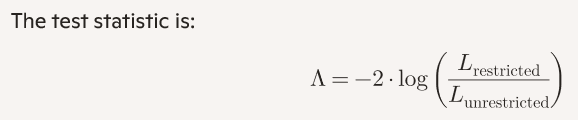

Now we have 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'

So we need to check if 'SepalLengthCm', 'SepalWidthCm' are sufficient to cretae model with > 90% accureacy

So Our full models = {'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'}

reduce models = {'SepalLengthCm', 'SepalWidthCm'}

 Interpretation
- Low p-value (< 0.05): Reject the null hypothesis → the full model fits significantly better.
- High p-value: Fail to reject → the restricted model is sufficient


#### Fit the Restricted Model

In [73]:

X_restricted = df[df['Species'] != 'Iris-virginica']
X_restricted = X_restricted.drop(['PetalLengthCm', 'PetalWidthCm','Species'],axis='columns')
X_restricted = sm.add_constant(X_restricted)
LogLink = sm.genmod.families.links.Log()
glm_Guss = sm.GLM(y, X_restricted, family=sm.families.Gaussian(link=LogLink))
restricted_models = glm_Guss.fit(maxiter=21)
#print(restricted_models.summary())

In [74]:
model_full       = res_guss_log
model_restricted = restricted_models

In [75]:
llf_full = model_full.llf
llf_restricted = model_restricted.llf
df_diff = model_full.df_model - model_restricted.df_model

lr_stat = -2 * (llf_restricted - llf_full)
p_value = stats.chi2.sf(lr_stat, df_diff)

print(f"LR stat: {lr_stat:.4f}, p-value: {p_value:.4f}, df diff: {df_diff}")
if p_value < 0.05: 
    print('Reject the null hypothesis → the full model fits significantly better.')
else:
    print('Fail to reject → the restricted model is sufficient') 

LR stat: 141.3030, p-value: 0.0000, df diff: 2
Reject the null hypothesis → the full model fits significantly better.


In [76]:
pred_probs_full = model_full.predict(X)
pred_probs_full_lable = (pred_probs_full > 0.9).astype(int)
pred_probs_restricted = model_restricted.predict(X_restricted)
accuracy_full = (pred_probs_full_lable == y).mean()
accuracy_restricted = (pred_probs_restricted == y).mean()
print(f'accureacy of full model {accuracy_restricted}, accureacy of restricted models {accuracy_restricted}')

accureacy of full model 0.0, accureacy of restricted models 0.0


***I received unexpected results after multiple attempts and cannot debug further at this time. I will revisit this when I have more time. I tested the dataset with all distributions in the exponential family and various link functions, but consistently received incorrect results.***